In [1]:
from astropy.io import fits
from pathlib import Path
import numpy as np
import sys
import numpy
from matplotlib.pyplot import figure, show, subplots
import numpy.ma as ma

#This is a shared cell between variable star group 1 and variable star group 2

datadir = "/net/virgo01/data/users/oassenberg/ObsAs/i"  #my data folder
 
#this sets the path that the program has to follow to get to our data!
path = Path(datadir)
filepaths_ = []
for filepath in path.iterdir():
    filepaths_.append(filepath)

filepaths = np.array(filepaths_)

filepaths.sort()

#285 - 295 -> Biases 

#363 and 637 and 609 and 758 missing!
BIAS = []

for i in range(0, 10):
    BIAS.append(filepaths[i])
for i in range(798-289, 809-289):
    BIAS.append(filepaths[i])


DARK = []

for i in range(11, 17):
    DARK.append(filepaths[i])
for i in range(783-289, 796-289):
    DARK.append(filepaths[i])


FLATB = []

for i in range(303-285, 307-285):
    FLATB.append(filepaths[i])
for i in range(812-289, 814-289):
    FLATB.append(filepaths[i])


FLATV = []

for i in range(308-285, 312-285):
    FLATV.append(filepaths[i])
for i in range(815-289, 817-289):
    FLATV.append(filepaths[i])


FLATR = []

for i in range(314-285, 319-285):
    FLATR.append(filepaths[i])
for i in range(809-289, 811-289):
    FLATR.append(filepaths[i])


LIGHTR = []
LIGHTV = []
LIGHTB = []
special = []

for i in range(363-285, 604-286, 3):
    LIGHTR.append(filepaths[i])
for i in range(365-286, 604-286, 3):
    LIGHTV.append(filepaths[i])
for i in range(366-286, 604-286, 3):
    LIGHTB.append(filepaths[i])
for i in range(604-286, 610-286):
    special.append(filepaths[i])

print(special)
for i in range(616-287, 636-287, 3):
    LIGHTR.append(filepaths[i])
for i in range(617-287, 636-287, 3):
    LIGHTV.append(filepaths[i])
for i in range(618-287, 636-287, 3):
    LIGHTB.append(filepaths[i])
    
for i in range(638-288, 758-289, 3):
    LIGHTR.append(filepaths[i])
for i in range(639-288, 758-289, 3):
    LIGHTV.append(filepaths[i])
for i in range(640-288, 758-289, 3):
    LIGHTB.append(filepaths[i])



GD336 = []
for i in range(759-289, 774-289):
    GD336.append(filepaths[i])

#Oli group is BV
#Grace group is VR
hdu = fits.open(LIGHTV[0])
print(hdu[0].header)

[PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000604.Mouse_click_position.RED.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000605.Mouse_click_position.GREEN.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000606.Mouse_click_position.BLUE.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000607.Mouse_click_position.RED.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000608.Mouse_click_position.GREEN.FIT'), PosixPath('/net/virgo01/data/users/oassenberg/ObsAs/i/260430_LI_.00000610.GCVS_YZ____Boo.FIT')]
SIMPLE  =                    T/CCDSOFT-SOFTWARE BISQUE 3                        BITPIX  =                   16                                                  NAXIS   =                    2                                                  NAXIS1  =                 1024                                                  NAXIS2  =                  682                  

Shape of data cube with stacked images: (21, 682, 1024)


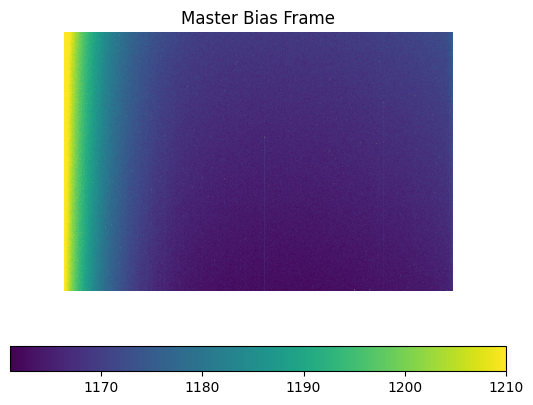

In [2]:
BIAS_file = []


for i in range(len(BIAS)):
    hdul = fits.open(BIAS[i])
    BIAS_file.append(hdul[0].data)

datacube = np.stack(BIAS_file)
print(f"Shape of data cube with stacked images: {datacube.shape}")


stacked_BIAS = np.median(datacube, axis=0)
fig, ax = subplots()


j = ax.imshow(stacked_BIAS, vmax = np.percentile(stacked_BIAS, 99), vmin = np.percentile(stacked_BIAS, 1), origin = 'lower')
ax.set_axis_off()
ax.set_title('Master Bias Frame')
fig.colorbar(j, orientation = 'horizontal')
ax.invert_yaxis()




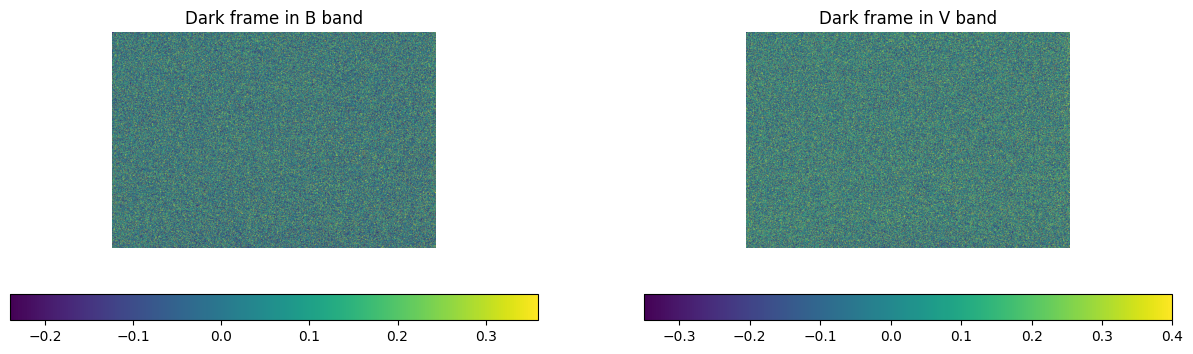

In [3]:
DARKR = []
DARKB = []
DARKV = []
for i in range(-15, -10):
    hdul = fits.open(DARK[i])
    DARKR.append((hdul[0].data - stacked_BIAS)/15)

for i in range(-10, -5):
    hdul = fits.open(DARK[i])
    DARKB.append((hdul[0].data - stacked_BIAS)/25)

for i in range(-5, 0):
    hdul = fits.open(DARK[i])
    DARKV.append((hdul[0].data - stacked_BIAS)/20)


datacubeR = np.stack(DARKR)
datacubeB = np.stack(DARKB)
datacubeV = np.stack(DARKV)


Stack_DARKR = np.median(datacubeR, axis=0)
Stack_DARKB = np.median(datacubeB, axis=0)
Stack_DARKV = np.median(datacubeV, axis=0)

fig1, ax1 = subplots(1,2, figsize = (15,4))
ax1 = ax1.flatten()


ax1[0].set_title('Dark frame in B band')
DarkB = ax1[0].imshow(Stack_DARKB, vmax = np.percentile(Stack_DARKB, 95), vmin = np.percentile(Stack_DARKB, 5), origin = 'lower')
fig1.colorbar(DarkB, orientation = 'horizontal')
ax1[0].set_axis_off()

ax1[1].set_title('Dark frame in V band')
DarkV = ax1[1].imshow(Stack_DARKV, vmax = np.percentile(Stack_DARKV, 95), vmin = np.percentile(Stack_DARKV, 5), origin = 'lower')
fig1.colorbar(DarkV, orientation = 'horizontal')
ax1[1].set_axis_off()

[array([[1402, 1458, 1468, ..., 1406, 1432, 1418],
       [1448, 1490, 1478, ..., 1402, 1438, 1422],
       [1404, 1495, 1487, ..., 1446, 1414, 1437],
       ...,
       [1386, 1427, 1460, ..., 1415, 1420, 1407],
       [1382, 1443, 1447, ..., 1416, 1414, 1415],
       [1361, 1460, 1457, ..., 1420, 1422, 1433]],
      shape=(682, 1024), dtype=uint16), array([[1400, 1485, 1474, ..., 1423, 1404, 1423],
       [1461, 1504, 1486, ..., 1420, 1475, 1436],
       [1412, 1507, 1481, ..., 1429, 1437, 1430],
       ...,
       [1389, 1465, 1482, ..., 1427, 1409, 1434],
       [1401, 1477, 1477, ..., 1406, 1416, 1422],
       [1389, 1463, 1470, ..., 1452, 1439, 1430]],
      shape=(682, 1024), dtype=uint16), array([[1382, 1433, 1420, ..., 1391, 1382, 1361],
       [1439, 1431, 1423, ..., 1395, 1371, 1397],
       [1378, 1439, 1442, ..., 1374, 1384, 1393],
       ...,
       [1365, 1431, 1411, ..., 1401, 1379, 1377],
       [1331, 1424, 1416, ..., 1356, 1353, 1376],
       [1350, 1395, 1423, ..., 

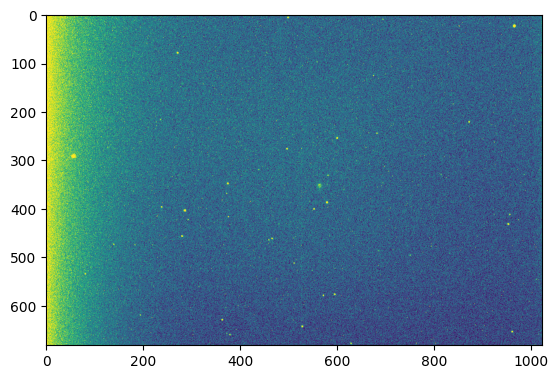

In [4]:
special_fi = []
for i in special:
    hdu = fits.open(i)
    special_fi.append(hdu[0].data)
print(special_fi)
figure, axes = subplots()
for i in special_fi:
    axes.imshow(i, vmax = np.percentile(i, 99), vmin = np.percentile(i, 1), norm = 'log')

In [5]:
FLATB_2 = []
FLATV_2 = []


for i in range(3, len(FLATB)):
    hdul = fits.open(FLATB[i])
    Corr = (hdul[0].data - stacked_BIAS - Stack_DARKB)
    FLATB_2.append((Corr)/np.median(Corr))

FLATB_corr = np.median(np.stack(FLATB_2), axis = 0)
                       
for i in range(3, len(FLATV)):
    hdul = fits.open(FLATV[i])
    Corr = (hdul[0].data - stacked_BIAS - Stack_DARKV)
    FLATV_2.append((Corr)/np.median(Corr))

FLATV_corr = np.median(np.stack(FLATV_2), axis = 0)


Text(0.5, 1.0, 'FLat field in V filter')

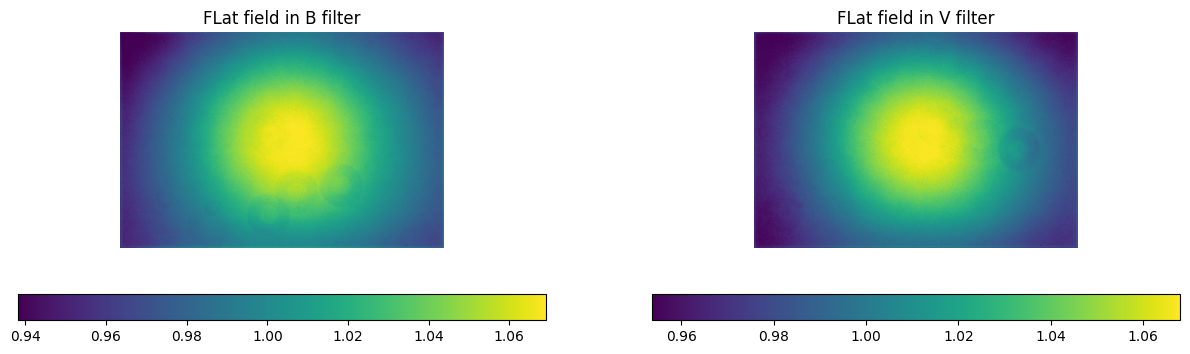

In [6]:
fig2, ax2 = subplots(1,2, figsize = (15,4))
ax2 = ax2.flatten()


imB = ax2[0].imshow(FLATB_corr, vmax = np.percentile(FLATB_corr, 99), vmin = np.percentile(FLATB_corr, 1), origin = 'lower')
fig2.colorbar(imB, orientation = 'horizontal')
ax2[0].set_axis_off()
ax2[0].set_title('FLat field in B filter')


imV = ax2[1].imshow(FLATV_corr, vmax = np.percentile(FLATV_corr, 99), vmin = np.percentile(FLATV_corr, 1), origin = 'lower')
fig2.colorbar(imV, orientation = 'horizontal')
ax2[1].set_axis_off()
ax2[1].set_title('FLat field in V filter')

In [7]:
# Reducing data

LIGHTB_reduced = []
LIGHTV_reduced = []
special_reduced =[]

for lightb in LIGHTB:
    hdul = fits.open(lightb)
    res = (hdul[0].data - stacked_BIAS - Stack_DARKB*25)/FLATB_corr
    LIGHTB_reduced.append(res)

for lightv in LIGHTV:
    hdul = fits.open(lightv)
    res = (hdul[0].data - stacked_BIAS - Stack_DARKV*20)/FLATV_corr
    LIGHTV_reduced.append(res)



In [8]:
#use astroalign register
#data reduce before aligning 

[262.44993023 262.49066502  13.90156015]


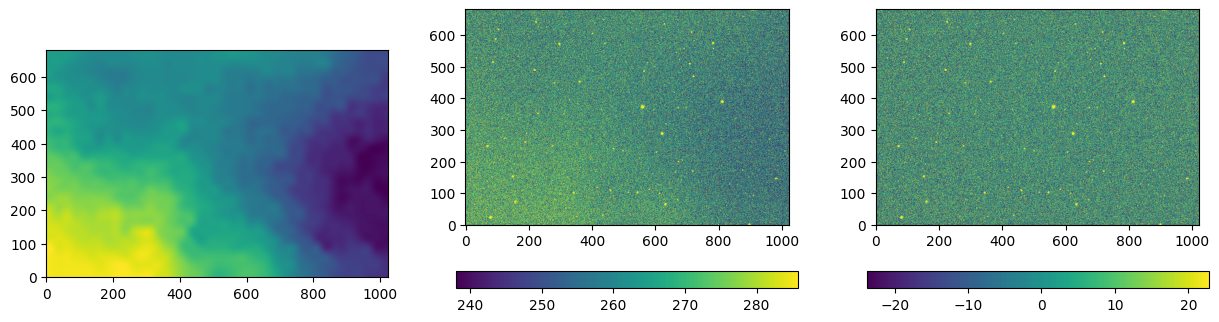

In [30]:
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground
from astropy.stats import sigma_clipped_stats, SigmaClip
from photutils.segmentation import detect_threshold, detect_sources
from photutils.utils import circular_footprint


sigma_clip = SigmaClip(sigma=10, maxiters=10)
threshold = detect_threshold(LIGHTV_reduced[80], nsigma=2.0, sigma_clip=sigma_clip)
segment_img = detect_sources(LIGHTV_reduced[80], threshold, npixels=10)
footprint = circular_footprint(radius=10)
mask = segment_img.make_source_mask(footprint=footprint)
mean, median, std = sigma_clipped_stats(LIGHTV_reduced[80], sigma=3.0, mask=mask)
print(np.array((mean, median, std)))

bkg = Background2D(LIGHTV_reduced[80], (25, 25), filter_size=(3, 3), mask=mask, sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)

fig45, ax45 = subplots(1,3, figsize = (15,4))
ax45 = ax45.flatten()
back = bkg.background
ax45[0].imshow(back, origin='lower')
k = ax45[1].imshow(LIGHTV_reduced[80], vmax = np.percentile(LIGHTV_reduced[80], 95), vmin = np.percentile(LIGHTV_reduced[80], 5), origin = 'lower')
fig45.colorbar(k, orientation = 'horizontal')
corr = (LIGHTV_reduced[80] - back)
l = ax45[2].imshow(corr, vmax = np.percentile(corr, 95), vmin = np.percentile(corr, 5), origin = 'lower')
fig45.colorbar(l, orientation = 'horizontal')